# 3\. Joins between Tables

## Task 3.1

- Take another look at the results from task 1.5.
- They contain a category no. but no descriptive category name.
- You can find the corresponding name in the ProductCategory table.
- Extends the query to add the descriptive category name as the "Category Name" column.

In [2]:
-- Query from Task 1.5
USE AdventureWorks2017
GO

SELECT ps.ProductSubcategoryID, ps.ProductCategoryID
       , ps.Name AS 'Subcategory Name', ps.ModifiedDate, pc.Name AS 'Category Name'
FROM Production.ProductSubcategory ps
INNER JOIN Production.ProductCategory pc
ON ps.ProductCategoryID = pc.ProductCategoryID
WHERE ps.Name LIKE '%Bike%'
ORDER BY [Subcategory Name];


Commands completed successfully.

(5 rows affected)

Total execution time: 00:00:00.017

ProductSubcategoryID,ProductCategoryID,Subcategory Name,ModifiedDate,Category Name
26,4,Bike Racks,2008-04-30 00:00:00.000,Accessories
27,4,Bike Stands,2008-04-30 00:00:00.000,Accessories
1,1,Mountain Bikes,2008-04-30 00:00:00.000,Bikes
2,1,Road Bikes,2008-04-30 00:00:00.000,Bikes
3,1,Touring Bikes,2008-04-30 00:00:00.000,Bikes


## Task 3.2

- Now we extend the query from task 3.1 with details about the product in question.
- To do this, add the ProductID as "Product ID" and the product name as "Product Name" from the Product table.

In [4]:
SELECT ps.ProductSubcategoryID, ps.ProductCategoryID
       , ps.Name AS 'Subcategory Name', ps.ModifiedDate, pc.Name AS 'Category Name',
       p.Name, p.ProductID
FROM Production.ProductSubcategory ps
INNER JOIN Production.ProductCategory pc
ON ps.ProductCategoryID = pc.ProductCategoryID
INNER JOIN Production.Product p
ON ps.ProductSubcategoryID = p.ProductSubcategoryID
WHERE ps.Name LIKE '%Bike%'
ORDER BY [Subcategory Name];

(99 rows affected)

Total execution time: 00:00:00.077

ProductSubcategoryID,ProductCategoryID,Subcategory Name,ModifiedDate,Category Name,Name,ProductID
26,4,Bike Racks,2008-04-30 00:00:00.000,Accessories,Hitch Rack - 4-Bike,876
27,4,Bike Stands,2008-04-30 00:00:00.000,Accessories,All-Purpose Bike Stand,879
1,1,Mountain Bikes,2008-04-30 00:00:00.000,Bikes,"Mountain-100 Silver, 38",771
1,1,Mountain Bikes,2008-04-30 00:00:00.000,Bikes,"Mountain-100 Silver, 42",772
1,1,Mountain Bikes,2008-04-30 00:00:00.000,Bikes,"Mountain-100 Silver, 44",773
1,1,Mountain Bikes,2008-04-30 00:00:00.000,Bikes,"Mountain-100 Silver, 48",774
1,1,Mountain Bikes,2008-04-30 00:00:00.000,Bikes,"Mountain-100 Black, 38",775
1,1,Mountain Bikes,2008-04-30 00:00:00.000,Bikes,"Mountain-100 Black, 42",776
1,1,Mountain Bikes,2008-04-30 00:00:00.000,Bikes,"Mountain-100 Black, 44",777
1,1,Mountain Bikes,2008-04-30 00:00:00.000,Bikes,"Mountain-100 Black, 48",778


## Task 3.3

- Extend the following Query to make it easier to read: Replace the VendorID and ShipMethodID with the descriptive name.
- The data for the descriptive names can be found in the Vendor and ShipMethod tables.
- This example shows you a self join which is also possible to solfe some specific problems  
    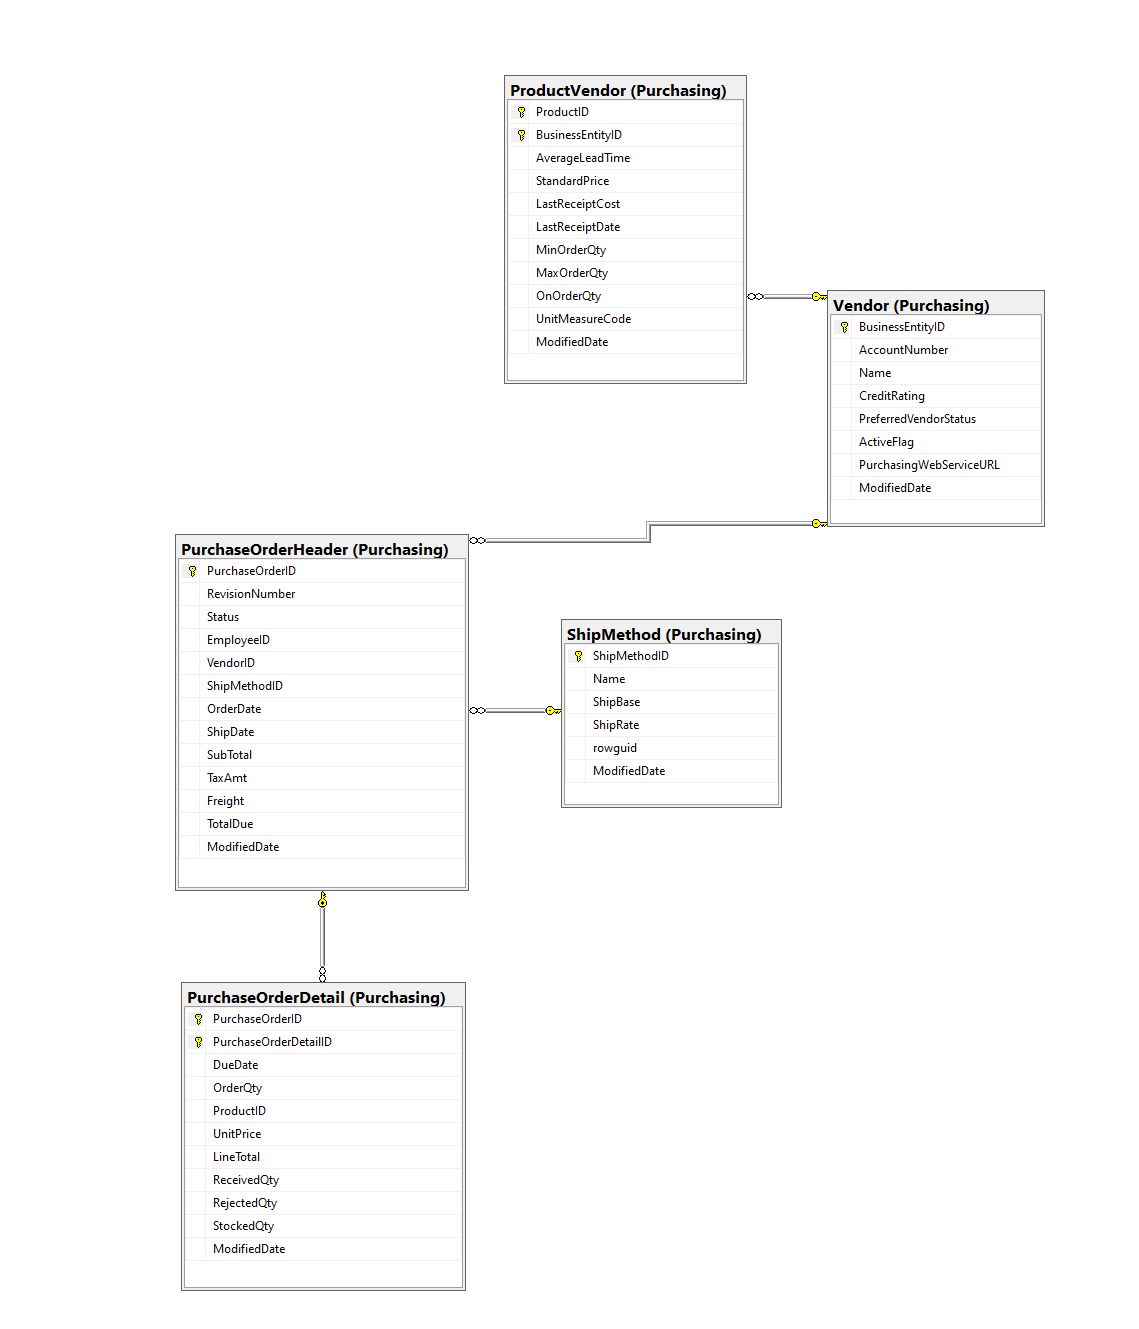

In [2]:
USE AdventureWorks2017
GO

SELECT a.PurchaseOrderID
       , b.PurchaseOrderID
       , v.Name AS 'Vendor Name'
       , sm.Name
FROM Purchasing.PurchaseOrderHeader AS a
INNER JOIN Purchasing.PurchaseOrderHeader AS b
ON a.VendorID = b.VendorID
   AND a.ShipMethodID = b.ShipMethodID
INNER JOIN Purchasing.Vendor v 
ON a.VendorID = v.BusinessEntityID
INNER JOIN Purchasing.ShipMethod sm 
ON a.ShipMethodID = sm.ShipMethodID
WHERE a.PurchaseOrderID < b.PurchaseOrderID;


: Msg 208, Level 16, State 1, Line 1
Invalid object name 'Purchasing.PurchaseOrderHeader'.

Total execution time: 00:00:00.008

## Task 3.4

- SQL Server stores its metadata in the sys schema You can find all tables in each database in the sys.tables view and all schemas of the database in the sys.schemas view.
- Using this knowledge, write a query that returns all tables with the associated schema of the AdventureWorks database that contain the word "Business" in the name.

In [13]:


SELECT CONCAT(s.Name, '.',t.Name) AS Tablename FROM sys.tables t
INNER JOIN sys.schemas s ON  t.schema_id = s.schema_id
WHERE t.name like '%Product%'
ORDER BY s.name, t.name

(16 rows affected)

Total execution time: 00:00:00.042

Tablename
Production.Product
Production.ProductCategory
Production.ProductCostHistory
Production.ProductDescription
Production.ProductDocument
Production.ProductInventory
Production.ProductListPriceHistory
Production.ProductModel
Production.ProductModelIllustration
Production.ProductModelProductDescriptionCulture


## Task 3.5

- Extend the queries from task 2.4 so that the descriptive name is displayed instead of the ProductSubCategoryID (information can be found in the ProductSubcategory table).
- The field with the descriptive name should have the heading "Subcatname“.

In [18]:
--Code from Exercise 2.4
SELECT ps.Name
    , MIN(p.ListPrice) AS 'Minimum'
    , MAX(p.ListPrice) AS 'Maximum'
    , AVG(p.ListPrice) AS 'Average'
 FROM Production.Product p
 INNER JOIN Production.ProductSubcategory ps
 ON p.productsubcategoryid = ps.productsubcategoryid
 WHERE p.ProductSubcategoryID IS NOT NULL
 GROUP BY ps.Name;

(37 rows affected)

Total execution time: 00:00:00.074

Name,Minimum,Maximum,Average
Mountain Bikes,"539,99","3399,99","1683,365"
Road Bikes,"539,99","3578,27","1597,45"
Touring Bikes,"742,35","2384,07","1425,2481"
Handlebars,"44,54","120,27","73,89"
Bottom Brackets,"53,99","121,49","92,24"
Brakes,"106,50","106,50","106,50"
Chains,"20,24","20,24","20,24"
Cranksets,"175,49","404,99","278,99"
Derailleurs,"91,49","121,46","106,475"
Forks,"148,22","229,49","184,40"
